# Phase 4: Distribution Analysis and Outlier Detection

## Purpose

This notebook analyzes the distribution of important numerical columns and detects outliers in the retail orders dataset.

Project 1 focused on cleaning and validating the dataset.  
Project 2 focuses on Exploratory Data Analysis.

In this phase, the goal is to understand how values are spread and identify unusual records that may represent important business signals.

Main question:

What patterns and outliers can we discover from order values, product prices, quantities, and cart sizes?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv("../data/processed/ecommerce_orders_project2_verified.csv")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,HasCoupon
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,Coupon Used
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,Coupon Used
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,Coupon Used
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,Coupon Used
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,Coupon Used


In [3]:
os.makedirs("../reports/figures", exist_ok=True)

print("Figures folder is ready.")

Figures folder is ready.


In [4]:
numeric_columns = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

df[numeric_columns].head()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
0,5,570.62,7,2853.10
1,2,151.35,3,302.70
2,5,550.68,8,2753.40
3,1,273.19,5,273.19
4,4,626.01,8,2504.04


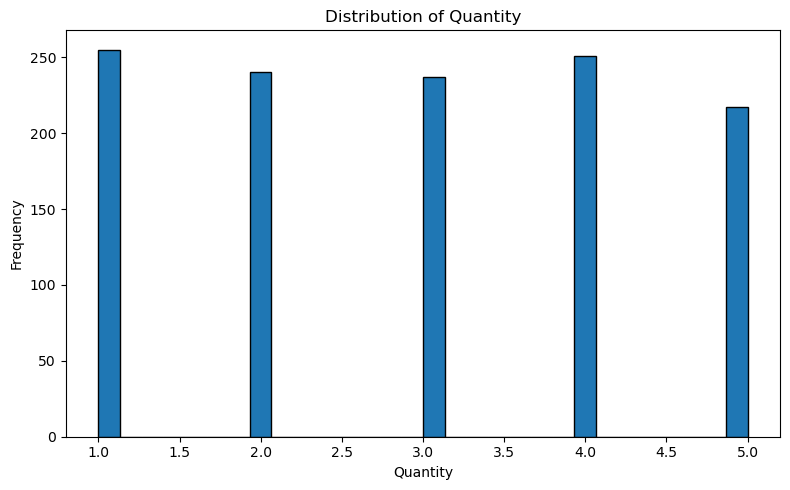

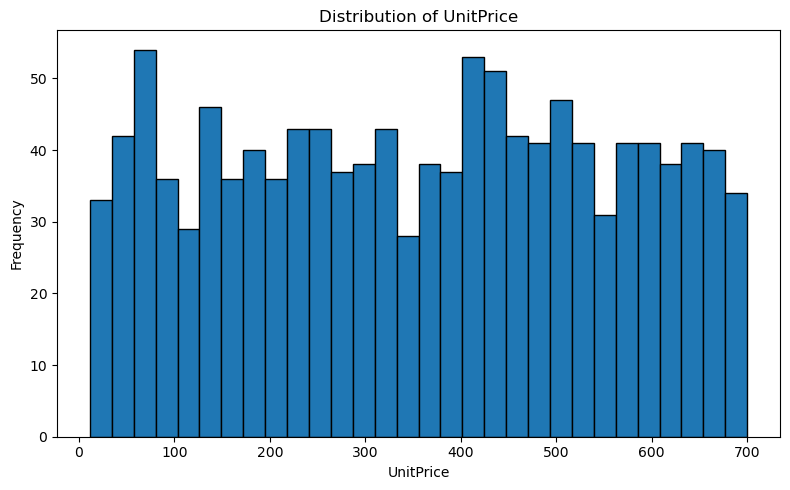

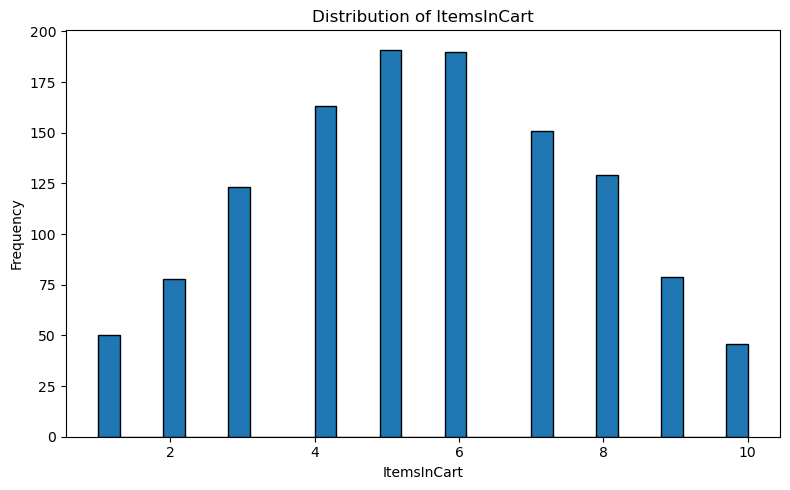

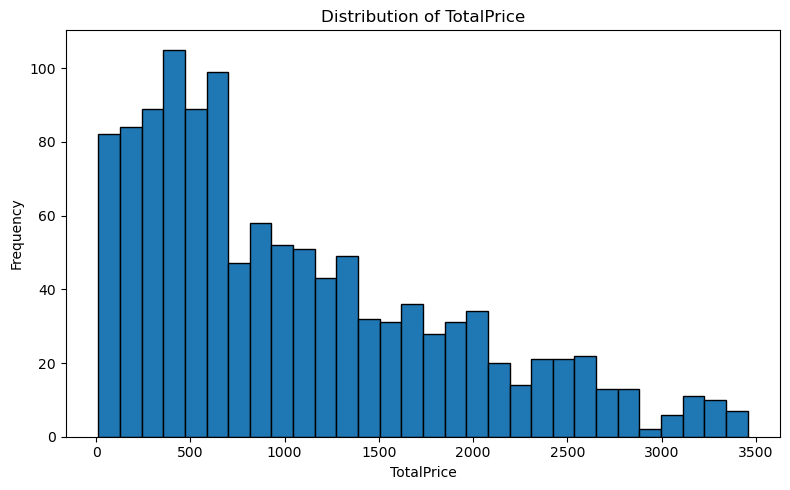

In [5]:
for col in numeric_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"../reports/figures/distribution_{col}.png")
    plt.show()

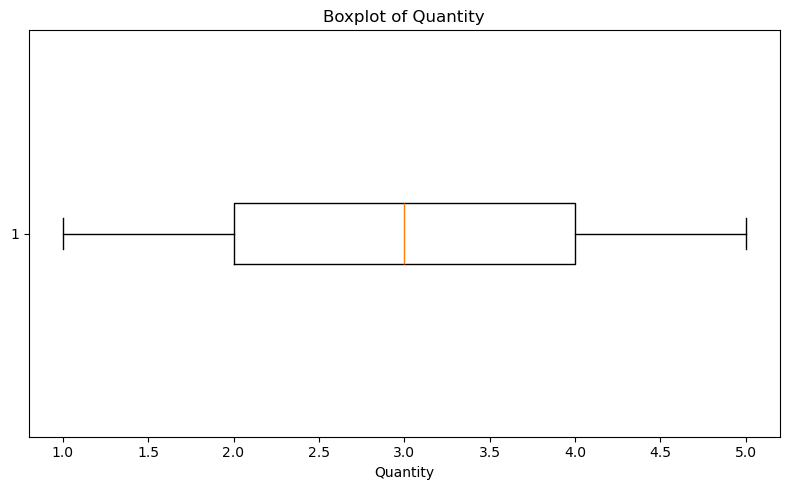

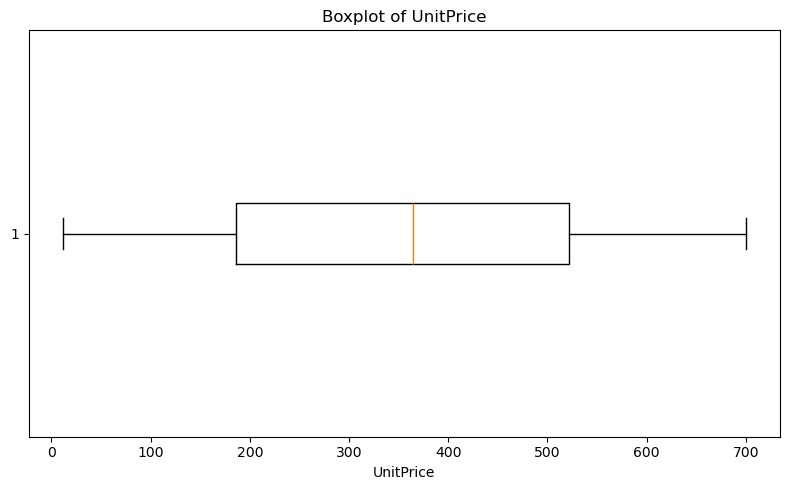

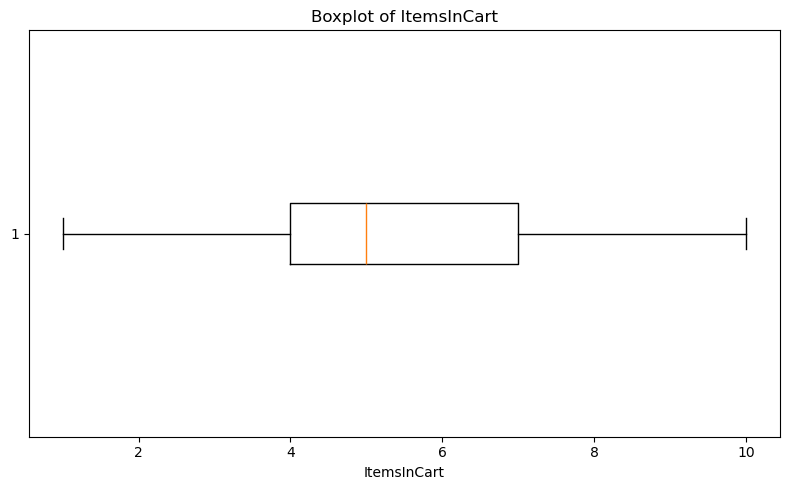

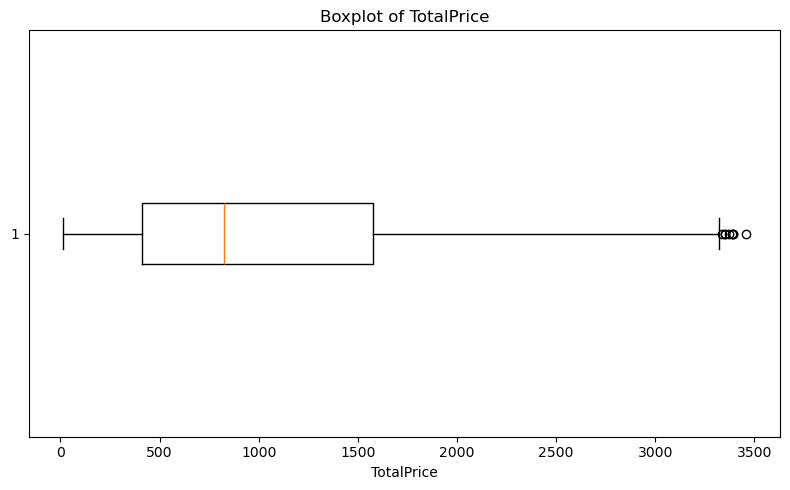

In [6]:
for col in numeric_columns:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(f"../reports/figures/boxplot_{col}.png")
    plt.show()

In [7]:
skewness_summary = pd.DataFrame({
    "Column": numeric_columns,
    "Skewness": [round(df[col].skew(), 2) for col in numeric_columns]
})

skewness_summary

,Column,Skewness
0,Quantity,0.03
1,UnitPrice,-0.03
2,ItemsInCart,0.00
3,TotalPrice,0.89


In [8]:
skewness_summary.to_csv("../reports/skewness_summary.csv", index=False)

print("Skewness summary saved successfully.")

Skewness summary saved successfully.


In [9]:
def detect_iqr_outliers(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = dataframe[
        (dataframe[column] < lower_bound) |
        (dataframe[column] > upper_bound)
    ]
    
    return Q1, Q3, IQR, lower_bound, upper_bound, outliers

In [10]:
iqr_outlier_summary = []

for col in numeric_columns:
    Q1, Q3, IQR, lower_bound, upper_bound, outliers = detect_iqr_outliers(df, col)
    
    iqr_outlier_summary.append({
        "Column": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": len(outliers)
    })

iqr_outlier_summary_df = pd.DataFrame(iqr_outlier_summary)

iqr_outlier_summary_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Quantity,2.00,4.00,2.00,-1.00,7.00,0
1,UnitPrice,186.06,521.57,335.51,-317.20,1024.83,0
2,ItemsInCart,4.00,7.00,3.00,-0.50,11.50,0
3,TotalPrice,410.52,1578.48,1167.96,-1341.41,3330.41,8


In [11]:
iqr_outlier_summary_df.to_csv("../reports/iqr_outlier_summary.csv", index=False)

print("IQR outlier summary saved successfully.")

IQR outlier summary saved successfully.


In [20]:
# Detect TotalPrice outliers using IQR

total_Q1, total_Q3, total_IQR, total_lower_bound, total_upper_bound, totalprice_outliers = detect_iqr_outliers(df, "TotalPrice")

totalprice_outliers[
    ["OrderID", "Date", "CustomerID", "Product", "Quantity", "UnitPrice", "TotalPrice", 
     "PaymentMethod", "OrderStatus", "ReferralSource", "HasCoupon"]
].sort_values(by="TotalPrice", ascending=False)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,TotalPrice,PaymentMethod,OrderStatus,ReferralSource,HasCoupon
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,3456.40,Online,Delivered,Email,Coupon Used
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,3390.95,Online,Returned,Facebook,No Coupon
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,3390.80,Gift Card,Delivered,Facebook,Coupon Used
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,3384.90,Cash,Cancelled,Facebook,No Coupon
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,3370.20,Online,Cancelled,Google,Coupon Used
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,3353.75,Gift Card,Shipped,Instagram,Coupon Used
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,3352.40,Gift Card,Returned,Facebook,Coupon Used
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,3334.00,Debit Card,Delivered,Referral,Coupon Used


In [21]:
totalprice_outliers.to_csv("../reports/totalprice_iqr_outliers.csv", index=False)

print("TotalPrice outliers saved successfully.")

TotalPrice outliers saved successfully.


In [22]:
zscore_summary = [] #z score outlier detection

for col in numeric_columns:
    mean_value = df[col].mean()
    std_value = df[col].std()
    
    df[f"{col}_ZScore"] = (df[col] - mean_value) / std_value
    
    outlier_count = df[
        (df[f"{col}_ZScore"] > 3) |
        (df[f"{col}_ZScore"] < -3)
    ].shape[0]
    
    zscore_summary.append({
        "Column": col,
        "Mean": round(mean_value, 2),
        "Standard Deviation": round(std_value, 2),
        "Z-score Outlier Count": outlier_count
    })

zscore_summary_df = pd.DataFrame(zscore_summary)

zscore_summary_df

,Column,Mean,Standard Deviation,Z-score Outlier Count
0,Quantity,2.95,1.41,0
1,UnitPrice,356.41,197.18,0
2,ItemsInCart,5.48,2.28,0
3,TotalPrice,1053.97,819.86,0


In [24]:
zscore_summary_df.to_csv("../reports/zscore_outlier_summary.csv", index=False)

print("Z-score outlier summary saved successfully.")

Z-score outlier summary saved successfully.


In [25]:
outlier_method_comparison = iqr_outlier_summary_df.merge(
    zscore_summary_df[["Column", "Z-score Outlier Count"]],
    on="Column"
)

outlier_method_comparison

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Z-score Outlier Count
0,Quantity,2.00,4.00,2.00,-1.00,7.00,0,0
1,UnitPrice,186.06,521.57,335.51,-317.20,1024.83,0,0
2,ItemsInCart,4.00,7.00,3.00,-0.50,11.50,0,0
3,TotalPrice,410.52,1578.48,1167.96,-1341.41,3330.41,8,0


In [26]:
outlier_method_comparison.to_csv("../reports/outlier_method_comparison.csv", index=False)

print("Outlier method comparison saved successfully.")

Outlier method comparison saved successfully.


In [27]:
# Create outlier flag column for TotalPrice using IQR limits

df["TotalPrice_Outlier_IQR"] = np.where(
    (df["TotalPrice"] < total_lower_bound) | (df["TotalPrice"] > total_upper_bound),
    "Outlier",
    "Normal"
)

df["TotalPrice_Outlier_IQR"].value_counts()

TotalPrice_Outlier_IQR
Normal     1192
Outlier       8
Name: count, dtype: int64

In [28]:
# Drop temporary Z-score columns before saving, unless you want to keep them
zscore_columns = [col for col in df.columns if col.endswith("_ZScore")]
df = df.drop(columns=zscore_columns)

df.to_csv("../data/processed/ecommerce_orders_project2_eda_ready.csv", index=False)

print("EDA-ready dataset with outlier flag saved successfully.")

EDA-ready dataset with outlier flag saved successfully.


## Distribution and Outlier Analysis Summary

This phase analyzed the distribution of important numerical columns in the retail orders dataset.

The numerical columns analyzed were:

- Quantity
- UnitPrice
- ItemsInCart
- TotalPrice

### Distribution Analysis

Histograms were created to understand how values are spread across the dataset.

This helps identify whether values are balanced, skewed, or concentrated in certain ranges.

Boxplots were also created to show the five-number summary and possible outliers.

The five-number summary includes:

- Minimum
- Q1
- Median
- Q3
- Maximum

### Outlier Detection

Outliers were detected using two methods:

1. IQR method
2. Z-score method

The IQR method was used as the main method because it is more suitable for business datasets that may not follow a perfect normal distribution.

The Z-score method was used as a secondary check.

### Business Interpretation

Outliers were not automatically removed.

In Project 1, unusual values were mainly checked for data quality issues.

In Project 2, unusual values are treated as possible business signals.

For example, a high TotalPrice order may represent a valuable customer order, not an error.

### Key Findings From This Phase

- Quantity, UnitPrice, and ItemsInCart did not show IQR outliers.
- TotalPrice showed 8 outliers using the IQR method.
- The highest TotalPrice outlier was 3,456.40.
- TotalPrice had positive skewness, meaning some high-value orders pull the distribution to the right.
- Z-score did not detect outliers, which suggests the outliers are not extreme enough under the standard deviation method.
- IQR is more useful for this dataset because retail order values are not perfectly normally distributed.

### Business Meaning

The 8 TotalPrice outliers should not be removed automatically.

These records are likely valid high-value orders because TotalPrice was already verified in Project 2 as Quantity × UnitPrice.

Therefore, these outliers can be treated as business signals instead of data errors.

They may represent valuable customer purchases, premium product sales, or important revenue opportunities.

### Conclusion

This phase helped identify the spread of key numerical variables and detect unusual order values.

The dataset is now ready for deeper EDA, including trend analysis, correlation analysis, and business category analysis.